# Testing speed of training

As a logistic regression is fitted for every sample it is a valid and important question how quick the different methods are for different sample sizes.

In [9]:
## Setting "base directory" for allowing imports
import os
import sys
import warnings

base_path = os.path.abspath("./..")
if base_path not in sys.path:
    sys.path.append(base_path)


# ============================
# Third-party imports
# ============================
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import statsmodels.api as sm
from statsmodels.genmod import families
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression

# ============================
# Local project imports
# ============================
from berebasl.BASL.classifiers import TorchLogistic
from berebasl.simulation.credit_data_simulation import CreditData, CreditDataGenerator
from dev.compare_torchlogit import fit_glm, fit_sklearn, fit_torch

# ============================
# Global configuration
# ============================
torch.set_default_dtype(torch.float64)
torch.set_printoptions(precision=6)
# Supurious warning which was corrected in github repo but not
# in the current sci-kit learn release
warnings.filterwarnings(
    "ignore",
    message="Setting penalty=None will ignore the C and l1_ratio parameters"
)


In [2]:
l2_norm = lambda arr : np.linalg.norm(arr, ord=2, axis=-1)
rel_l2_error = lambda new_beta, base_beta: l2_norm(new_beta - base_beta) / l2_norm(base_beta)
def compare_models_fit_to_glm(
        fitted_glm, glm_probs, 
        sk_lr, sk_probs,
        torch_lr, torch_probs
):
    stats = {}
    # Parameter comparision
    ml_calc_params = np.concatenate([
        np.concatenate([sk_lr.intercept_.reshape((1,-1)), sk_lr.coef_],axis=1),
        np.concatenate([torch_lr.lin_estimator.bias.detach().unsqueeze(0), torch_lr.lin_estimator.weight.detach()], axis=1)
        ])
    glm_params = fitted_glm.params.reshape((1,-1))

    stats["params_rel_l2_err_sk"], stats["params_rel_l2_err_torch"] = rel_l2_error(glm_params, ml_calc_params)

    joint_probs_ml_last_class = np.stack([sk_probs[...,-1], torch_probs[..., -1]],axis=0)
    glm_probs_last_class = np.expand_dims(glm_probs[..., -1], 0)
    probs_diffs_last_class = glm_probs_last_class - joint_probs_ml_last_class
    probs_diffs_last_class = probs_diffs_last_class.reshape(probs_diffs_last_class.shape[0], -1) #Flatten other axis if given, take all predictions per model.
    abs_probs_diffs = np.abs(probs_diffs_last_class)

    stats["probs_mae_sk"], stats["probs_mae_torch"] = np.abs(probs_diffs_last_class).mean(axis=-1)

    idx_worst = abs_probs_diffs.argmax(axis=-1)
    stats["probs_worst_err_sk"], stats["probs_worst_err_torch"] = probs_diffs_last_class[np.arange(idx_worst.shape[0]), idx_worst]
    
    same_preds_as_glm = (glm_probs_last_class > 0.5) == (joint_probs_ml_last_class > 0.5)
    stats["pred_proportion_eq_sk"], stats["pred_proportion_eq_torch"] = same_preds_as_glm.sum(axis=-1) / same_preds_as_glm.shape[-1]
    
    
    return stats

In [ ]:
# Taking over the args
initial_seed = 1807

sample_size = 100
holdout_sample = 3000
num_gens = 300

trials_per_gen = 500

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_gen = CreditDataGenerator.init_with_internal_logic(
    count_covariates=2,
    mean_bad_diff=torch.tensor([1.0,2.0]),
    covars = {
        "bad" : torch.tensor([[1.0, 0.2], [0.2,1.0]]),
        "good" : torch.tensor([[1.0,-0.2], [-0.2,1.0]])
    },
    iid = False,
    mixture_weights=None,
    bad_ratio = 0.5,
    noise_var=0.0,
    device = device,
    seed_credit_data_gen=initial_seed,
    #dtype=torch.get_default_dtype()
)

data_gen.manual_seed(initial_seed)
features, default_flag = data_gen.sample(100)

credit_data = CreditData(
    features, default_flag, 
    accepted_initial=torch.ones(default_flag.shape, dtype=torch.bool) # All are "accepted"
)
stats = []

for gen_nr in range(1, num_gens + 1):
    if gen_nr % 10 == 0:
        print("\n")
        print("-- Iteration", f"{gen_nr}/{num_gens}:", credit_data.accepted_count, 
              "accepts and", credit_data.rejected_count, " rejects")
        print("\n")

    data_gen.manual_seed(initial_seed + gen_nr)
    features, default_flag = data_gen.sample(100)
    credit_data.add_gen(
        features,
        default_flag,
        accepted_new=torch.ones(default_flag.shape, dtype=torch.bool)
    )

    features, default_flag = credit_data.return_whole_set(
        retrieve_only_accepted=True,
        transform=lambda features, default_flag, gen_round : (features.detach(), default_flag.detach())
    )
    current_gen_stats = []
    for trial_nr in range(trials_per_gen):
        fitted_glm, glm_probs, train_time_glm, inf_time_glm = fit_glm(
            X = features.numpy(), 
            label = default_flag.numpy()
        )
        sk_lr, sk_probs, train_time_sk, inf_time_sk = fit_sklearn(
            X = features.numpy(), 
            label = default_flag.numpy()
        )

        torch_lr, torch_probs, train_time_torch, inf_time_torch = fit_torch(
            X_torch = features, 
            label_torch = default_flag.unsqueeze(-1)
        )

        time_stats = {
            'train_time_glm' : train_time_glm,
            'inf_time_glm' : inf_time_glm,
            'train_time_sk' : train_time_sk,
            'inf_time_sk' : inf_time_sk,
            'train_time_torch' : train_time_torch,
            'inf_time_torch' : inf_time_torch
        }

        comp_to_glm_stats = compare_models_fit_to_glm(
            fitted_glm, glm_probs, sk_lr, sk_probs, torch_lr, torch_probs
        )

        current_gen_stats.append(pd.Series(time_stats | comp_to_glm_stats, name =(gen_nr, trial_nr)))


    current_gen_stats = pd.DataFrame(current_gen_stats)
    current_gen_stats["obs_count"] = len(credit_data)
    stats.append(current_gen_stats.copy())

stats = pd.concat(stats)    



-- Iteration 10/300: 1000 accepts and 0  rejects




-- Iteration 20/300: 2000 accepts and 0  rejects




-- Iteration 30/300: 3000 accepts and 0  rejects




-- Iteration 40/300: 4000 accepts and 0  rejects




-- Iteration 50/300: 5000 accepts and 0  rejects




-- Iteration 60/300: 6000 accepts and 0  rejects




-- Iteration 70/300: 7000 accepts and 0  rejects




-- Iteration 80/300: 8000 accepts and 0  rejects




-- Iteration 90/300: 9000 accepts and 0  rejects




-- Iteration 100/300: 10000 accepts and 0  rejects




-- Iteration 110/300: 11000 accepts and 0  rejects




-- Iteration 120/300: 12000 accepts and 0  rejects




-- Iteration 130/300: 13000 accepts and 0  rejects




-- Iteration 140/300: 14000 accepts and 0  rejects




-- Iteration 150/300: 15000 accepts and 0  rejects




-- Iteration 160/300: 16000 accepts and 0  rejects




-- Iteration 170/300: 17000 accepts and 0  rejects




-- Iteration 180/300: 18000 accepts and 0  rejects




-- Iteration 190/300: 1900

In [111]:
def grouper(group):
    agg_group = group.drop(columns="obs_count")
    grouping = pd.concat([agg_group.agg(["mean"]), agg_group.quantile([0.05, 0.95])])
    obs_count = group["obs_count"].iloc[0]
    grouping["obs_count"] = obs_count

    return grouping

grouped_stats = stats.groupby(level=0).apply(grouper).unstack(level=1)
grouped_stats.drop(columns=[("obs_count", 0.05), ("obs_count", 0.95)], inplace=True)

In [112]:
def scatter_with_minmax(ax, x, y, lower_q, higher_q, label, c, s=3):
    ax.scatter(
        x,
        y,
        label=label,
        s = s,
        c = c
    )
    ax.plot(
        x,
        lower_q,
        c= to_rgba(c)[:3] + (0.2,)
    )
    ax.plot(
        x,
        lower_q,
        c=to_rgba(c)[:3] + (0.2,)
    )
    ax.plot(
        x,
        higher_q,
        c=to_rgba(c)[:3] + (0.2,)
    )
    return ax

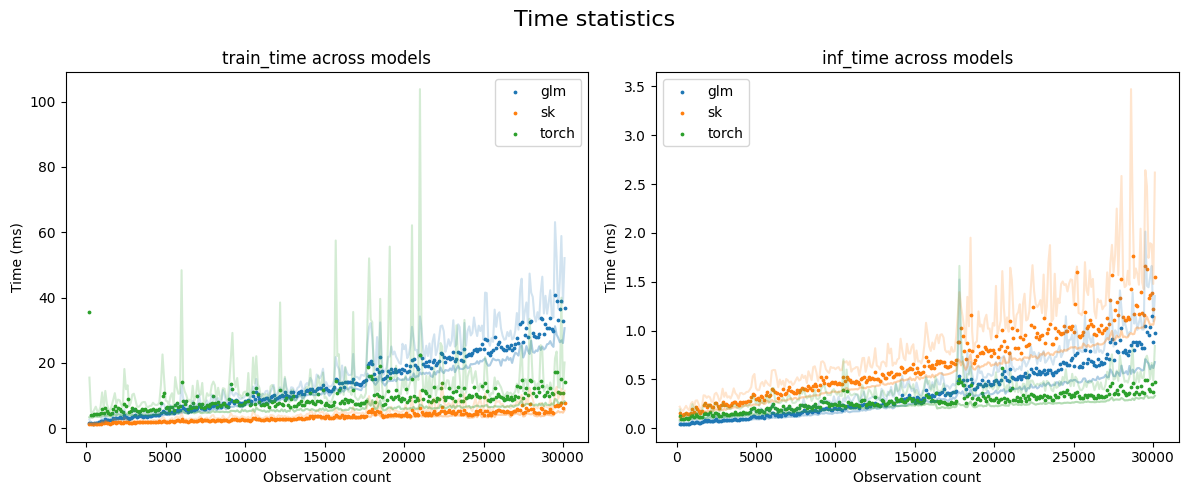

In [113]:
obs_counts = grouped_stats["obs_count"]["mean"]

models = ["glm", "sk", "torch"]

fig, axes = plt.subplots(ncols=2, figsize=(12,5))

colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

for ax, error_type in zip(axes, ["train", "inf"]):
    for model_idx, model in enumerate(models):
        scatter_with_minmax(
            ax,
            x=obs_counts,
            y=grouped_stats[f"{error_type}_time_{model}"]["mean"] * 1e3,
            lower_q=grouped_stats[f"{error_type}_time_{model}"][0.05] * 1e3,
            higher_q=grouped_stats[f"{error_type}_time_{model}"][0.95] * 1e3,
            label=model,
            c=colors[model_idx]
        )
    ax.legend()
    ax.set_title(f"{error_type}_time across models")
    ax.set_xlabel("Observation count")
    ax.set_ylabel("Time (ms)")

fig.suptitle("Time statistics", fontsize=16)

fig.tight_layout()

plt.show()

In [118]:
means = grouped_stats.swaplevel(0,1,axis="columns")["mean"]
time_means = means[[c for c in means.columns if "_time_" in c]]
time_means.describe().sort_index(axis=1)

,inf_time_glm,inf_time_sk,inf_time_torch,train_time_glm,train_time_sk,train_time_torch
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,0.000378,0.000675,0.000272,0.014428,0.003575,0.008965
std,0.000257,0.000350,0.000087,0.009175,0.001418,0.003185
min,0.000038,0.000131,0.000090,0.001352,0.001246,0.003963
25%,0.000158,0.000394,0.000215,0.006628,0.002406,0.007124
50%,0.000310,0.000612,0.000276,0.012322,0.003470,0.008399
75%,0.000562,0.000953,0.000326,0.021406,0.004671,0.010098
max,0.001146,0.001765,0.000615,0.040912,0.007747,0.035538


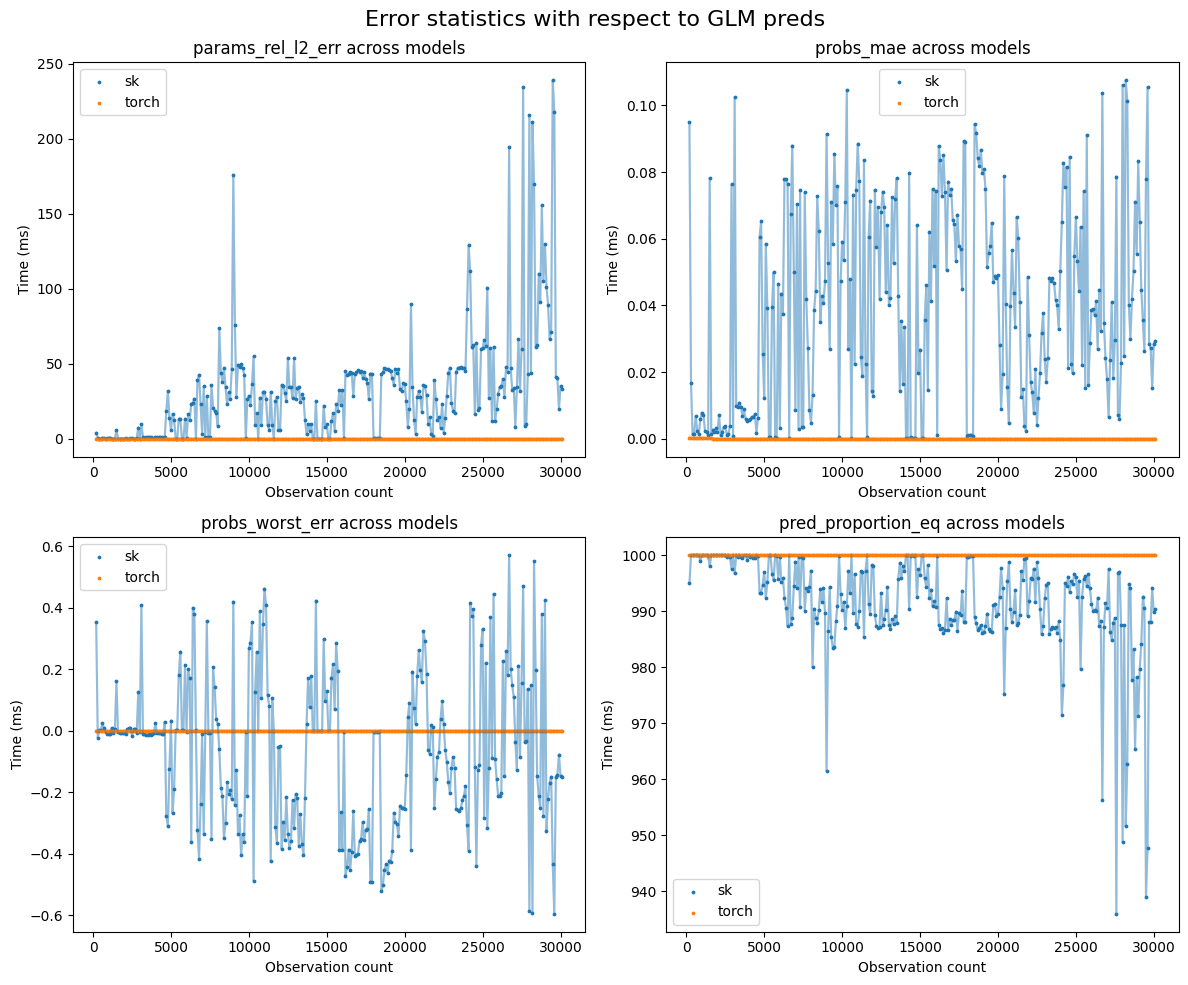

In [71]:
obs_counts = grouped_stats["obs_count"]["mean"]

models = ["glm", "sk", "torch"]

fig, axes = plt.subplots(nrows= 2, ncols=2, figsize=(12,10))

colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]


for ax, error_type in zip(axes.flatten(), ["params_rel_l2_err", "probs_mae", "probs_worst_err","pred_proportion_eq"]):
    for model_idx, model in enumerate(models[1:]):
        scatter_with_minmax(
            ax,
            x=obs_counts,
            y=grouped_stats[f"{error_type}_{model}"]["mean"] * 1e3,
            lower_q=grouped_stats[f"{error_type}_{model}"][0.05] * 1e3,
            higher_q=grouped_stats[f"{error_type}_{model}"][0.95] * 1e3,
            label=model,
            c=colors[model_idx]
        )
    ax.legend()
    ax.set_title(f"{error_type} across models")
    ax.set_xlabel("Observation count")
    ax.set_ylabel("Time (ms)")

fig.suptitle("Error statistics with respect to GLM preds", fontsize=16)

fig.tight_layout()

plt.show()